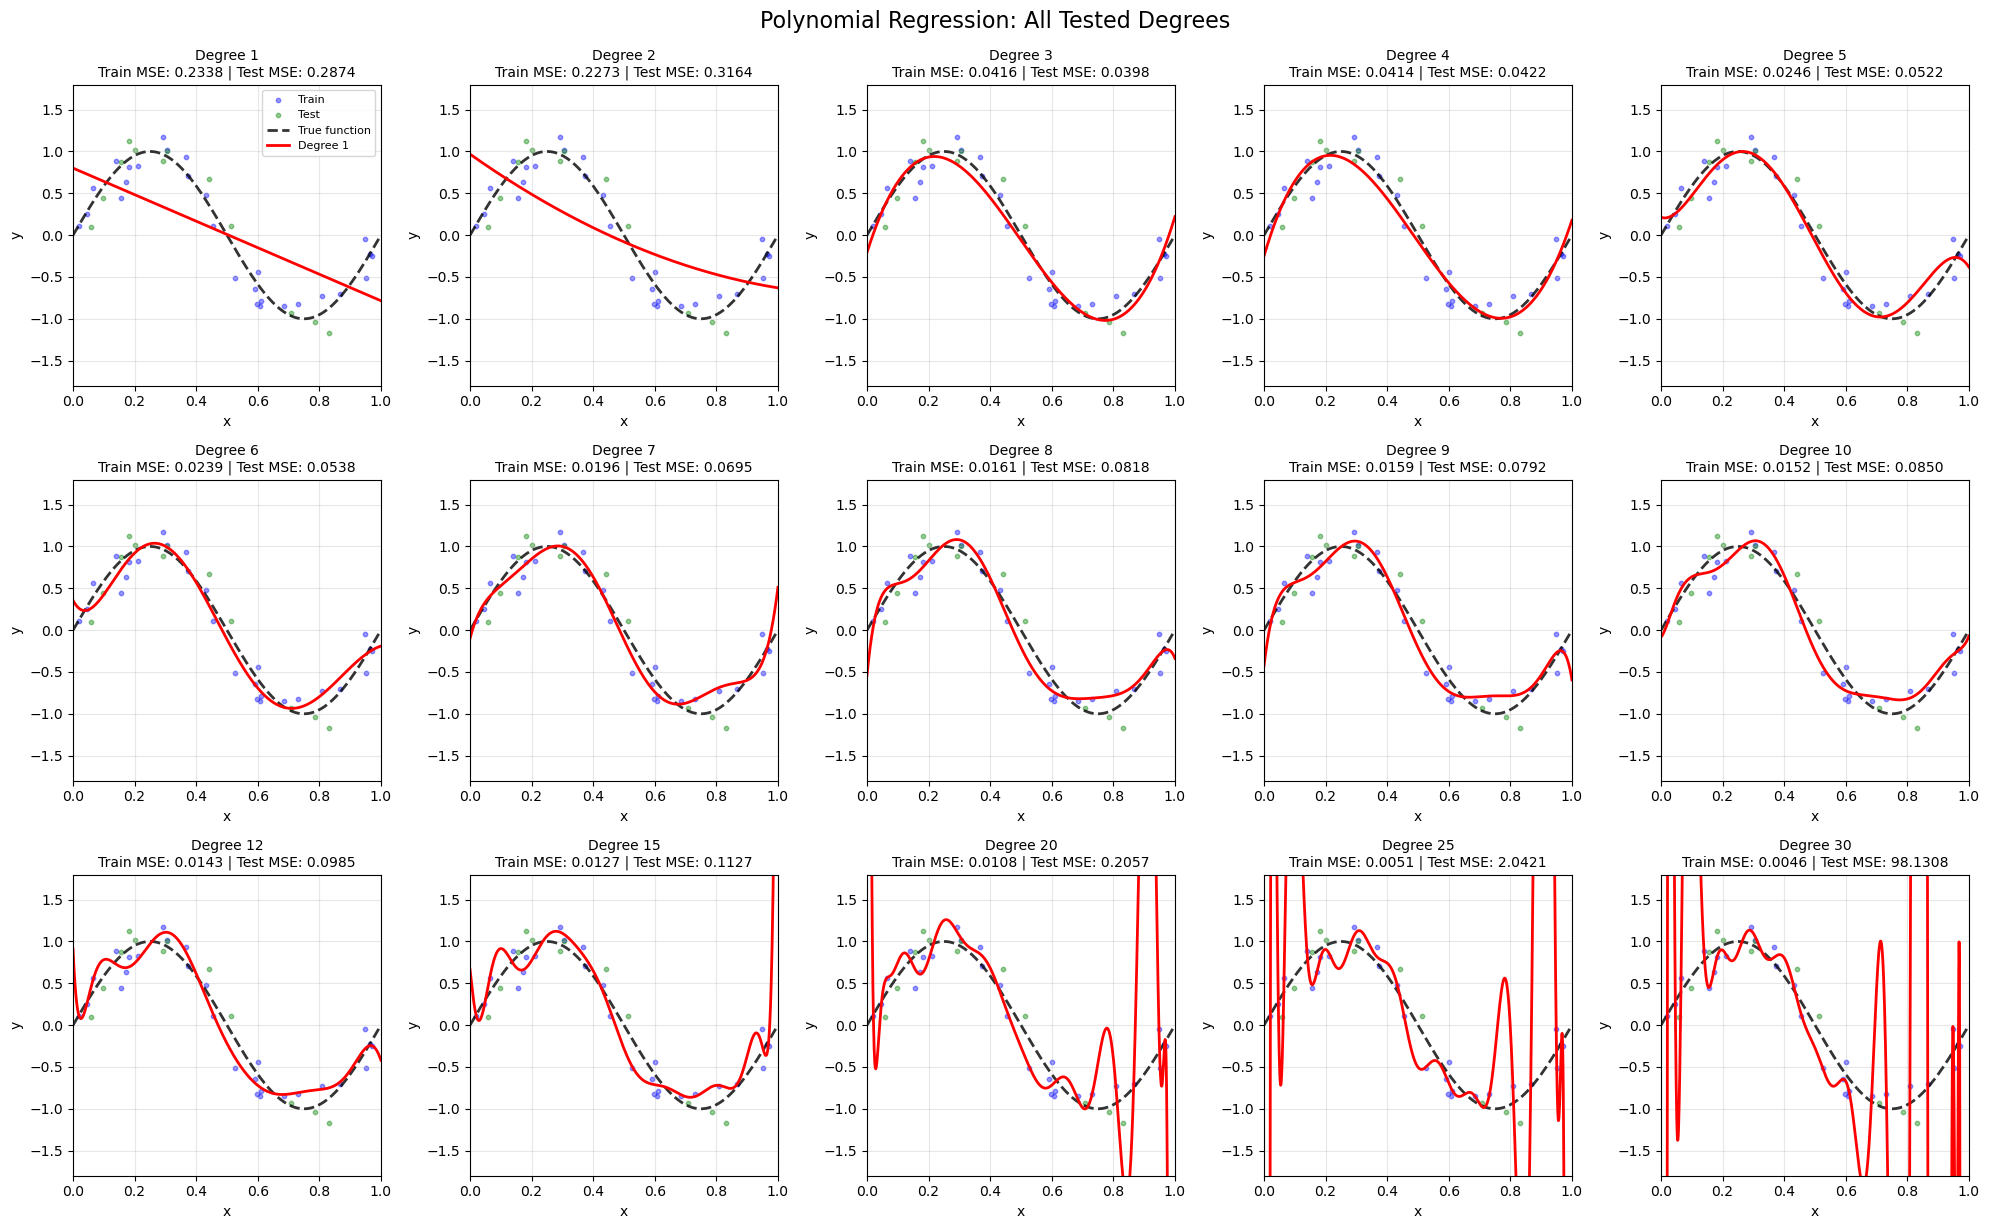

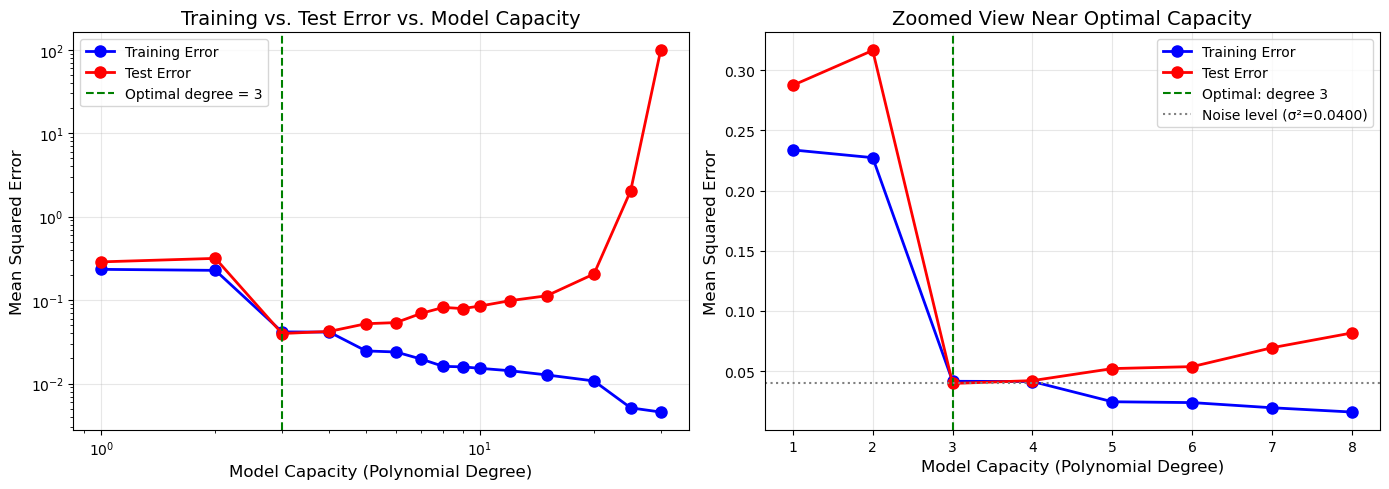

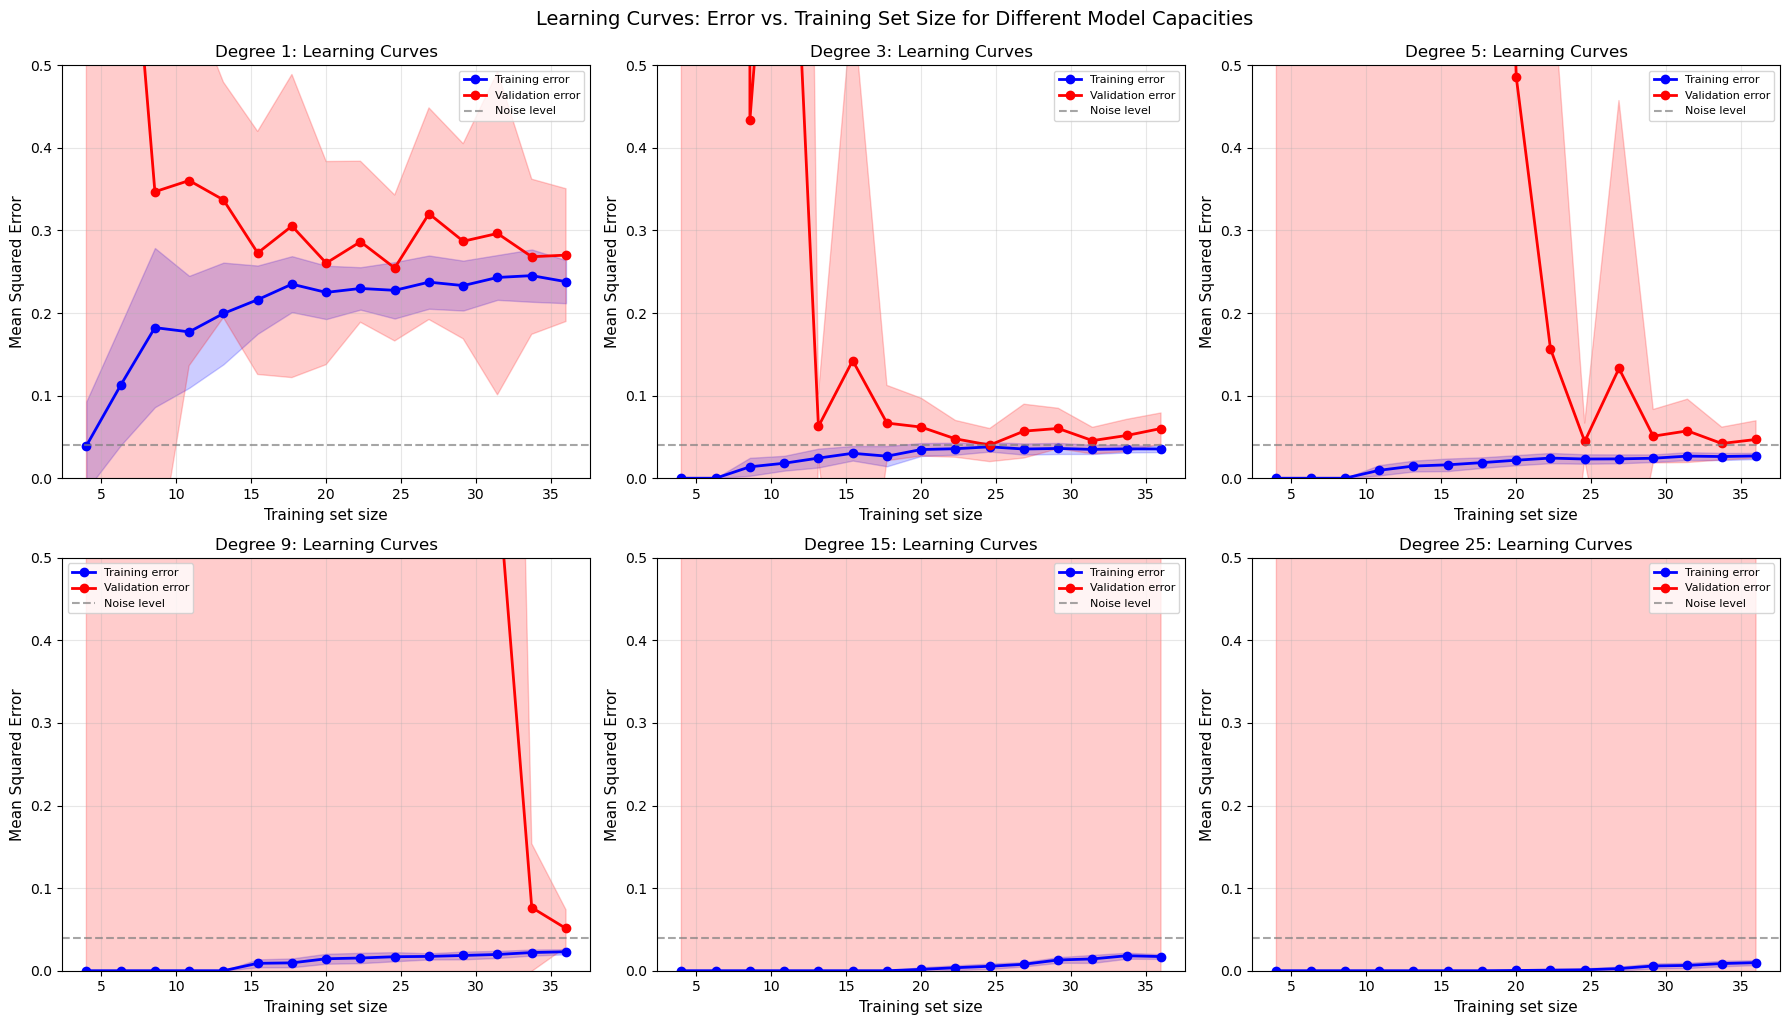

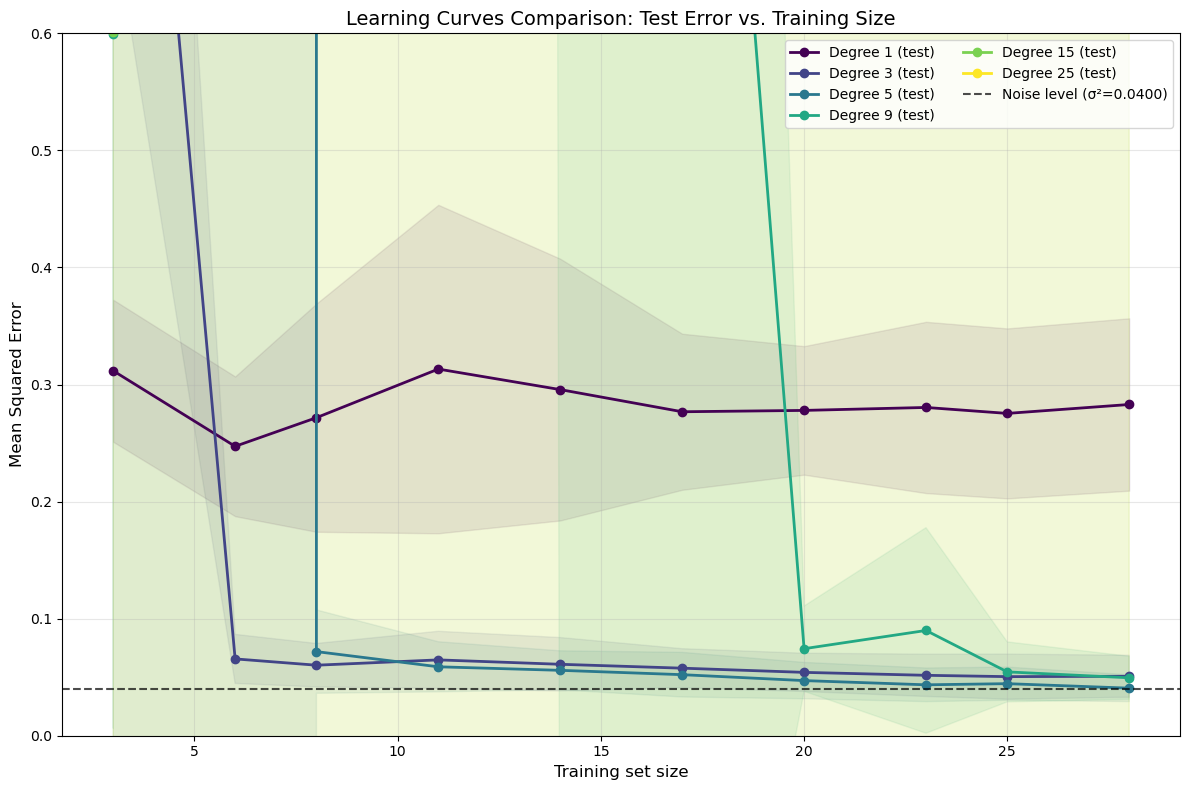

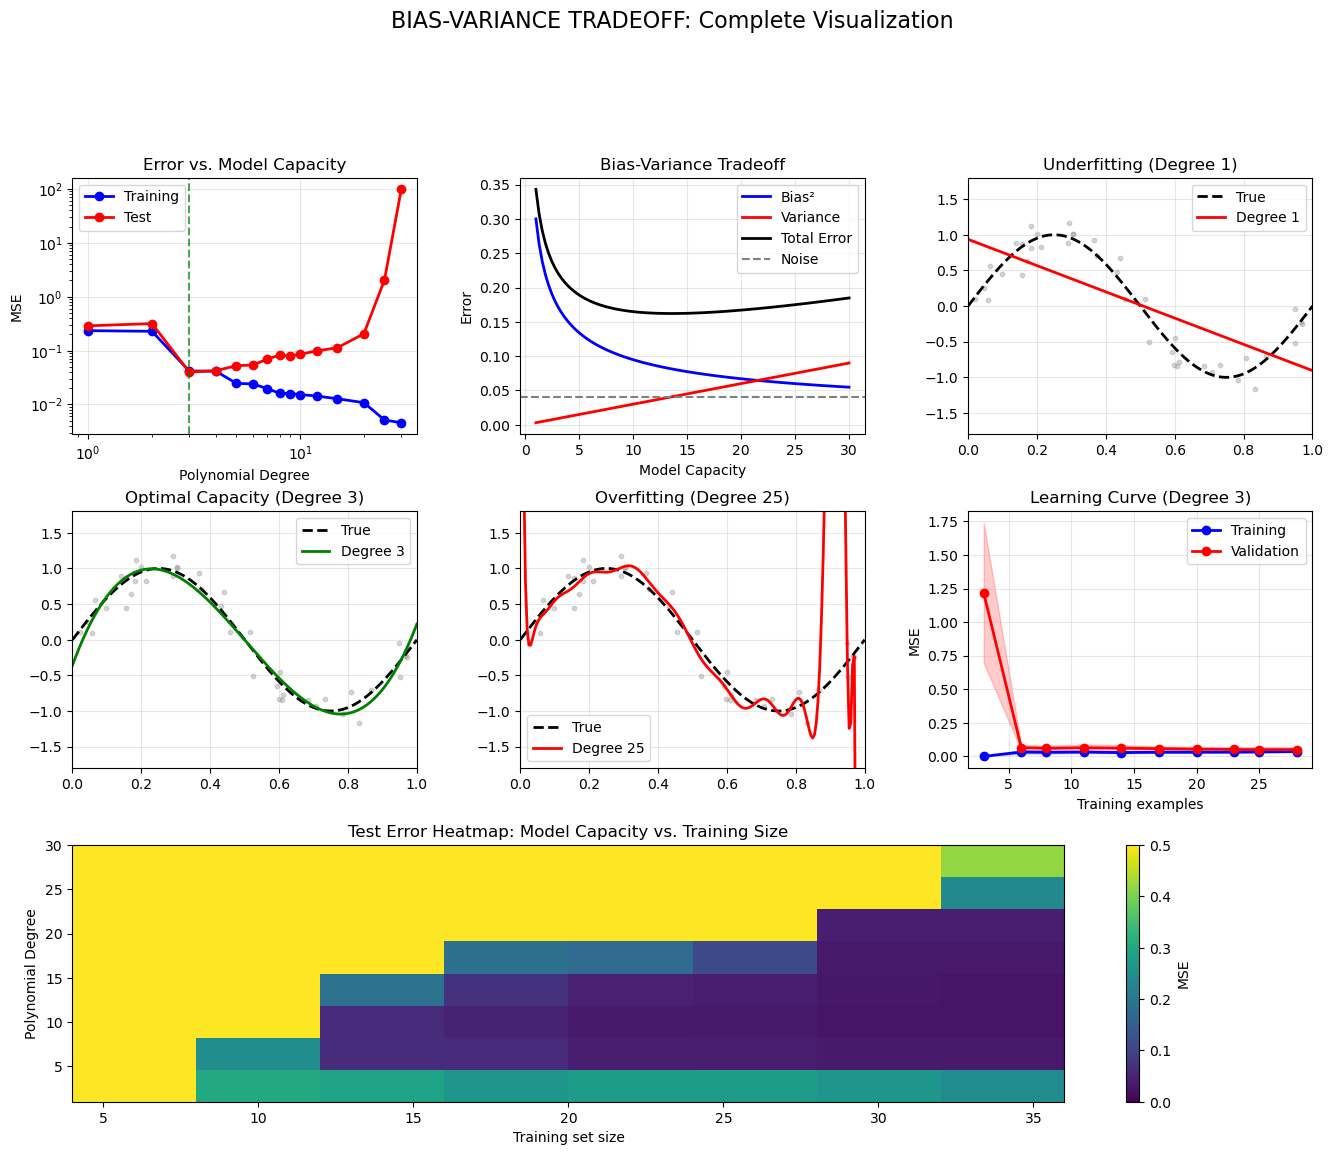


BIAS-VARIANCE TRADEOFF: COMPLETE ANALYSIS

--- MODEL CAPACITY ANALYSIS ---
Degree     Train MSE    Test MSE     Gap (Test-Train)   Interpretation      
------------------------------------------------------------------------
1          0.2338       0.2874       0.0537             High Bias           
2          0.2273       0.3164       0.0891             High Bias           
3          0.0416       0.0398       -0.0018            High Bias           
4          0.0414       0.0422       0.0008             Balanced            
5          0.0246       0.0522       0.0276             Balanced            
6          0.0239       0.0538       0.0299             Balanced            
7          0.0196       0.0695       0.0499             Balanced            
8          0.0161       0.0818       0.0657             Slight Overfit      
9          0.0159       0.0792       0.0633             Slight Overfit      
10         0.0152       0.0850       0.0697             Slight Overfit      
12  

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# ============================================================================
# 1. Generate the true function and noisy data
# ============================================================================

def true_sinusoidal_function(x):
    """True underlying function: sin(2πx)"""
    return np.sin(2 * np.pi * x)

# Generate data
n_samples = 40  # Increased for better learning curve analysis
X = np.random.uniform(0, 1, n_samples).reshape(-1, 1)
y_true = true_sinusoidal_function(X).flatten()

# Add noise
noise_std = 0.2
y_noisy = y_true + np.random.normal(0, noise_std, n_samples)

# Create test data (dense grid for smooth visualization)
X_test = np.linspace(0, 1, 1000).reshape(-1, 1)
y_test_true = true_sinusoidal_function(X_test).flatten()

# ============================================================================
# 2. Plot all tested degrees for polynomial regression
# ============================================================================

# Define degrees to test - more comprehensive range
degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30]

# Calculate optimal subplot grid
n_degrees = len(degrees)
n_cols = 5
n_rows = int(np.ceil(n_degrees / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

train_errors = []
test_errors = []
models = []

for i, degree in enumerate(degrees):
    # Split data for this run
    X_train, X_test_split, y_train, y_test_split = train_test_split(
        X, y_noisy, test_size=0.3, random_state=42
    )
    
    # Create polynomial regression model
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    
    # Fit model
    model.fit(X_train, y_train)
    models.append(model)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test_split)
    y_dense_pred = model.predict(X_test)
    
    # Calculate errors
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test_split, y_test_pred)
    
    train_errors.append(train_mse)
    test_errors.append(test_mse)
    
    # Plot
    ax = axes[i]
    
    # Plot training data
    ax.scatter(X_train, y_train, alpha=0.4, label='Train', color='blue', s=10)
    ax.scatter(X_test_split, y_test_split, alpha=0.4, label='Test', color='green', s=10)
    
    # Plot true function
    ax.plot(X_test, y_test_true, 'k--', label='True function', linewidth=2, alpha=0.8)
    
    # Plot fitted polynomial
    ax.plot(X_test, y_dense_pred, 'r-', label=f'Degree {degree}', linewidth=2)
    
    # Annotate with errors
    ax.set_title(f'Degree {degree}\nTrain MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}', fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(0, 1)
    ax.set_ylim(-1.8, 1.8)
    ax.grid(True, alpha=0.3)
    
    # Add legend only to first plot to save space
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('Polynomial Regression: All Tested Degrees', y=1.02, fontsize=16)
plt.show()

# ============================================================================
# 3. Training vs Test Error as Function of Model Capacity
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Error curves
ax1 = axes[0]
ax1.plot(degrees, train_errors, 'bo-', label='Training Error', linewidth=2, markersize=8)
ax1.plot(degrees, test_errors, 'ro-', label='Test Error', linewidth=2, markersize=8)
ax1.axvline(x=degrees[np.argmin(test_errors)], color='green', linestyle='--', 
            label=f'Optimal degree = {degrees[np.argmin(test_errors)]}')

ax1.set_xlabel('Model Capacity (Polynomial Degree)', fontsize=12)
ax1.set_ylabel('Mean Squared Error', fontsize=12)
ax1.set_title('Training vs. Test Error vs. Model Capacity', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

# Plot 2: Zoomed view around optimal capacity
ax2 = axes[1]
opt_idx = np.argmin(test_errors)
opt_degree = degrees[opt_idx]
zoom_degrees = degrees[max(0, opt_idx-5):min(len(degrees), opt_idx+6)]

ax2.plot(zoom_degrees, train_errors[max(0, opt_idx-5):min(len(degrees), opt_idx+6)], 
         'bo-', label='Training Error', linewidth=2, markersize=8)
ax2.plot(zoom_degrees, test_errors[max(0, opt_idx-5):min(len(degrees), opt_idx+6)], 
         'ro-', label='Test Error', linewidth=2, markersize=8)
ax2.axvline(x=opt_degree, color='green', linestyle='--', label=f'Optimal: degree {opt_degree}')
ax2.axhline(y=noise_std**2, color='gray', linestyle=':', label=f'Noise level (σ²={noise_std**2:.4f})')

ax2.set_xlabel('Model Capacity (Polynomial Degree)', fontsize=12)
ax2.set_ylabel('Mean Squared Error', fontsize=12)
ax2.set_title('Zoomed View Near Optimal Capacity', fontsize=14)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 4. Learning Curves (Error vs. Training Set Size)
# ============================================================================

# Select representative degrees for learning curves
learning_curve_degrees = [1, 3, 5, 9, 15, 25]
train_sizes = np.linspace(0.1, 0.9, 15)  # Fraction of training data

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, degree in enumerate(learning_curve_degrees):
    ax = axes[idx]
    
    train_scores_mean = []
    train_scores_std = []
    test_scores_mean = []
    test_scores_std = []
    
    for train_size in train_sizes:
        # Calculate number of samples for this train size
        n_train = int(train_size * n_samples)
        
        # Store scores for multiple runs
        train_fold_scores = []
        test_fold_scores = []
        
        for run in range(20):  # 20 runs for each train size
            # Sample random subset
            indices = np.random.choice(n_samples, n_train, replace=False)
            X_subset = X[indices]
            y_subset = y_noisy[indices]
            
            # Split into train and validation
            X_tr, X_te, y_tr, y_te = train_test_split(
                X_subset, y_subset, test_size=0.2, random_state=run
            )
            
            # Fit model
            model = make_pipeline(
                PolynomialFeatures(degree=degree, include_bias=False),
                LinearRegression()
            )
            model.fit(X_tr, y_tr)
            
            # Predict
            y_tr_pred = model.predict(X_tr)
            y_te_pred = model.predict(X_te)
            
            # Calculate errors
            train_fold_scores.append(mean_squared_error(y_tr, y_tr_pred))
            test_fold_scores.append(mean_squared_error(y_te, y_te_pred))
        
        train_scores_mean.append(np.mean(train_fold_scores))
        train_scores_std.append(np.std(train_fold_scores))
        test_scores_mean.append(np.mean(test_fold_scores))
        test_scores_std.append(np.std(test_fold_scores))
    
    # Convert to numpy arrays
    train_scores_mean = np.array(train_scores_mean)
    train_scores_std = np.array(train_scores_std)
    test_scores_mean = np.array(test_scores_mean)
    test_scores_std = np.array(test_scores_std)
    
    # Plot learning curves
    train_sizes_abs = train_sizes * n_samples
    ax.plot(train_sizes_abs, train_scores_mean, 'o-', color='blue', label='Training error', linewidth=2)
    ax.fill_between(train_sizes_abs, 
                    train_scores_mean - train_scores_std,
                    train_scores_mean + train_scores_std, 
                    alpha=0.2, color='blue')
    
    ax.plot(train_sizes_abs, test_scores_mean, 'o-', color='red', label='Validation error', linewidth=2)
    ax.fill_between(train_sizes_abs, 
                    test_scores_mean - test_scores_std,
                    test_scores_mean + test_scores_std, 
                    alpha=0.2, color='red')
    
    # Add horizontal line for noise level
    ax.axhline(y=noise_std**2, color='gray', linestyle='--', alpha=0.7, label=f'Noise level')
    
    ax.set_xlabel('Training set size', fontsize=11)
    ax.set_ylabel('Mean Squared Error', fontsize=11)
    ax.set_title(f'Degree {degree}: Learning Curves', fontsize=12)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 0.5)

plt.tight_layout()
plt.suptitle('Learning Curves: Error vs. Training Set Size for Different Model Capacities', y=1.02, fontsize=14)
plt.show()

# ============================================================================
# 5. Combined Learning Curves for Comparison
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 8))

# Define line styles and colors for different degrees
colors = plt.cm.viridis(np.linspace(0, 1, len(learning_curve_degrees)))

for idx, degree in enumerate(learning_curve_degrees):
    # Compute learning curve using sklearn's built-in function
    train_sizes_abs, train_scores, test_scores = learning_curve(
        make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), LinearRegression()),
        X, y_noisy, train_sizes=np.linspace(0.1, 0.9, 10),
        cv=5, scoring='neg_mean_squared_error', random_state=42
    )
    
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    # Plot test error (validation error)
    ax.plot(train_sizes_abs, test_scores_mean, 'o-', color=colors[idx], 
            label=f'Degree {degree} (test)', linewidth=2, markersize=6)
    ax.fill_between(train_sizes_abs, 
                    test_scores_mean - test_scores_std,
                    test_scores_mean + test_scores_std, 
                    alpha=0.1, color=colors[idx])

ax.axhline(y=noise_std**2, color='black', linestyle='--', alpha=0.7, label=f'Noise level (σ²={noise_std**2:.4f})')

ax.set_xlabel('Training set size', fontsize=12)
ax.set_ylabel('Mean Squared Error', fontsize=12)
ax.set_title('Learning Curves Comparison: Test Error vs. Training Size', fontsize=14)
ax.legend(loc='upper right', fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 0.6)

plt.tight_layout()
plt.show()

# ============================================================================
# 6. Summary Visualization: The Complete Picture
# ============================================================================

fig = plt.figure(figsize=(16, 12))

# Grid specification
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Main plot: Model capacity vs error (top left)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(degrees, train_errors, 'bo-', label='Training', linewidth=2, markersize=6)
ax1.plot(degrees, test_errors, 'ro-', label='Test', linewidth=2, markersize=6)
ax1.axvline(x=degrees[np.argmin(test_errors)], color='green', linestyle='--', alpha=0.7)
ax1.set_xlabel('Polynomial Degree')
ax1.set_ylabel('MSE')
ax1.set_title('Error vs. Model Capacity')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

# Top middle: Bias-Variance tradeoff (simplified representation)
ax2 = fig.add_subplot(gs[0, 1])
capacity = np.linspace(1, 30, 100)
bias = 1 / np.sqrt(capacity) * 0.3
variance = capacity / 100 * 0.3
total = bias + variance + noise_std**2

ax2.plot(capacity, bias, 'b-', label='Bias²', linewidth=2)
ax2.plot(capacity, variance, 'r-', label='Variance', linewidth=2)
ax2.plot(capacity, total, 'k-', label='Total Error', linewidth=2)
ax2.axhline(y=noise_std**2, color='gray', linestyle='--', label='Noise')
ax2.set_xlabel('Model Capacity')
ax2.set_ylabel('Error')
ax2.set_title('Bias-Variance Tradeoff')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Top right: Underfitting example
ax3 = fig.add_subplot(gs[0, 2])
degree_under = 1
model_under = make_pipeline(PolynomialFeatures(degree=degree_under), LinearRegression())
model_under.fit(X, y_noisy)
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
y_plot_under = model_under.predict(X_plot)

ax3.scatter(X, y_noisy, alpha=0.3, s=10, color='gray')
ax3.plot(X_plot, true_sinusoidal_function(X_plot), 'k--', label='True', linewidth=2)
ax3.plot(X_plot, y_plot_under, 'r-', label=f'Degree {degree_under}', linewidth=2)
ax3.set_title(f'Underfitting (Degree {degree_under})')
ax3.set_xlim(0, 1)
ax3.set_ylim(-1.8, 1.8)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Middle left: Optimal example
ax4 = fig.add_subplot(gs[1, 0])
degree_opt = degrees[np.argmin(test_errors)]
model_opt = make_pipeline(PolynomialFeatures(degree=degree_opt), LinearRegression())
model_opt.fit(X, y_noisy)
y_plot_opt = model_opt.predict(X_plot)

ax4.scatter(X, y_noisy, alpha=0.3, s=10, color='gray')
ax4.plot(X_plot, true_sinusoidal_function(X_plot), 'k--', label='True', linewidth=2)
ax4.plot(X_plot, y_plot_opt, 'g-', label=f'Degree {degree_opt}', linewidth=2)
ax4.set_title(f'Optimal Capacity (Degree {degree_opt})')
ax4.set_xlim(0, 1)
ax4.set_ylim(-1.8, 1.8)
ax4.legend()
ax4.grid(True, alpha=0.3)

# Middle middle: Overfitting example
ax5 = fig.add_subplot(gs[1, 1])
degree_over = 25
model_over = make_pipeline(PolynomialFeatures(degree=degree_over), LinearRegression())
model_over.fit(X, y_noisy)
y_plot_over = model_over.predict(X_plot)

ax5.scatter(X, y_noisy, alpha=0.3, s=10, color='gray')
ax5.plot(X_plot, true_sinusoidal_function(X_plot), 'k--', label='True', linewidth=2)
ax5.plot(X_plot, y_plot_over, 'r-', label=f'Degree {degree_over}', linewidth=2)
ax5.set_title(f'Overfitting (Degree {degree_over})')
ax5.set_xlim(0, 1)
ax5.set_ylim(-1.8, 1.8)
ax5.legend()
ax5.grid(True, alpha=0.3)

# Middle right: Learning curve for optimal model
ax6 = fig.add_subplot(gs[1, 2])
train_sizes_abs, train_scores, test_scores = learning_curve(
    make_pipeline(PolynomialFeatures(degree=degree_opt), LinearRegression()),
    X, y_noisy, train_sizes=np.linspace(0.1, 0.9, 10),
    cv=5, scoring='neg_mean_squared_error'
)

ax6.plot(train_sizes_abs, -np.mean(train_scores, axis=1), 'o-', color='blue', label='Training', linewidth=2)
ax6.plot(train_sizes_abs, -np.mean(test_scores, axis=1), 'o-', color='red', label='Validation', linewidth=2)
ax6.fill_between(train_sizes_abs, 
                 -np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
                 -np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), 
                 alpha=0.2, color='blue')
ax6.fill_between(train_sizes_abs, 
                 -np.mean(test_scores, axis=1) - np.std(test_scores, axis=1),
                 -np.mean(test_scores, axis=1) + np.std(test_scores, axis=1), 
                 alpha=0.2, color='red')
ax6.set_xlabel('Training examples')
ax6.set_ylabel('MSE')
ax6.set_title(f'Learning Curve (Degree {degree_opt})')
ax6.legend()
ax6.grid(True, alpha=0.3)

# Bottom row: Learning curves for all degrees (heatmap style)
ax7 = fig.add_subplot(gs[2, :])

# Create a matrix of test errors for different degrees and training sizes
degree_range = degrees[::2]  # Subset for clarity
train_size_range = np.linspace(0.1, 0.9, 8)
error_matrix = np.zeros((len(degree_range), len(train_size_range)))

for i, degree in enumerate(degree_range):
    for j, train_size in enumerate(train_size_range):
        n_train = int(train_size * n_samples)
        errors = []
        for seed in range(5):
            X_tr, X_te, y_tr, y_te = train_test_split(
                X, y_noisy, train_size=n_train, random_state=seed
            )
            model = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression())
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_te)
            errors.append(mean_squared_error(y_te, y_pred))
        error_matrix[i, j] = np.mean(errors)

im = ax7.imshow(error_matrix, aspect='auto', origin='lower', 
                extent=[train_size_range[0]*n_samples, train_size_range[-1]*n_samples, 
                        degree_range[0], degree_range[-1]],
                cmap='viridis', vmin=0, vmax=0.5)
ax7.set_xlabel('Training set size')
ax7.set_ylabel('Polynomial Degree')
ax7.set_title('Test Error Heatmap: Model Capacity vs. Training Size')
plt.colorbar(im, ax=ax7, label='MSE')

plt.suptitle('BIAS-VARIANCE TRADEOFF: Complete Visualization', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# 7. Print Summary Statistics
# ============================================================================

print("\n" + "="*80)
print("BIAS-VARIANCE TRADEOFF: COMPLETE ANALYSIS")
print("="*80)

print("\n--- MODEL CAPACITY ANALYSIS ---")
print(f"{'Degree':<10} {'Train MSE':<12} {'Test MSE':<12} {'Gap (Test-Train)':<18} {'Interpretation':<20}")
print("-"*72)

for i, degree in enumerate(degrees):
    gap = test_errors[i] - train_errors[i]
    
    if degree <= 3:
        interp = "High Bias"
    elif degree <= 7:
        interp = "Balanced"
    elif degree <= 12:
        interp = "Slight Overfit"
    else:
        interp = "High Variance"
    
    print(f"{degree:<10} {train_errors[i]:<12.4f} {test_errors[i]:<12.4f} {gap:<18.4f} {interp:<20}")

print("\n--- OPTIMAL MODEL ---")
opt_degree = degrees[np.argmin(test_errors)]
opt_train = train_errors[np.argmin(test_errors)]
opt_test = test_errors[np.argmin(test_errors)]
print(f"Optimal polynomial degree: {opt_degree}")
print(f"Training error: {opt_train:.4f}")
print(f"Test error: {opt_test:.4f}")
print(f"Generalization gap: {opt_test - opt_train:.4f}")
print(f"Noise level (σ²): {noise_std**2:.4f}")

print("\n--- LEARNING CURVE INSIGHTS ---")
print("• With few training samples, low-capacity models perform better")
print("• As training set size increases, high-capacity models improve")
print("• The optimal model capacity increases with more training data")
print("• The gap between training and test error decreases with more data")

print("\n" + "="*80)
print("KEY TAKEAWAYS:")
print("="*80)
print("""
1. UNDERFITTING (Low Capacity):
   - High bias, low variance
   - Training and test errors are both high
   - Model is too simple to capture the true pattern

2. OPTIMAL CAPACITY:
   - Balanced bias and variance
   - Minimum test error
   - Best generalization to unseen data

3. OVERFITTING (High Capacity):
   - Low bias, high variance
   - Training error is very low, but test error is high
   - Model fits noise in training data

4. LEARNING CURVES SHOW:
   - With small datasets, simple models are better
   - With large datasets, complex models can excel
   - The optimal complexity increases with data size
""")